In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import KernelDensity
from scipy import integrate

a Black Hole of mass $M$ and spin $a\in [0, 1]$ after Penrose processes has irreducible mass of:

$M_{irr}=M\sqrt{\frac{1+\sqrt{1-a^2}}{2}}$

$f(a)=M_{irr}/M=\sqrt{\frac{1+\sqrt{1-a^2}}{2}}$

Text(0.5, 1.0, 'f(a)')

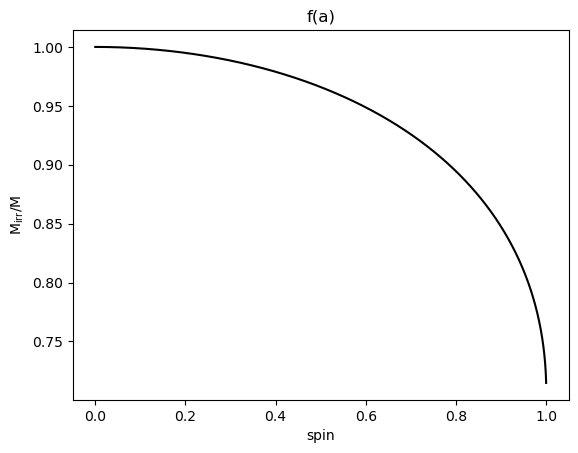

In [2]:
def f(a): #Mirr/M
    return np.sqrt((1+np.sqrt(1-a**2))/2)

N_BHs = 10000
a = np.random.uniform(low=0, high=1, size=N_BHs) #spin
plt.plot(np.sort(a), f(np.sort(a)), "k")
plt.xlabel("spin")
plt.ylabel("M$\\rm_{irr}/M$")
plt.title("f(a)")

Text(0.5, 1.0, 'M$\\rm_{irr}/M$ distribution')

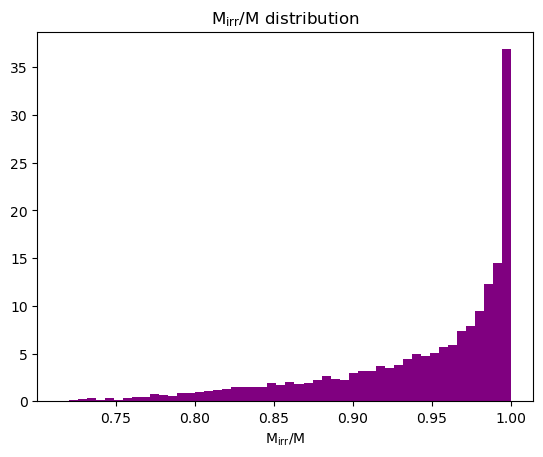

In [3]:
plt.hist(f(a), bins=50, color="purple", density=True)
plt.xlabel("M$\\rm_{irr}/M$")
plt.title("M$\\rm_{irr}/M$ distribution")

Text(0.5, 1.0, 'M$\\rm_{irr}$ distribution')

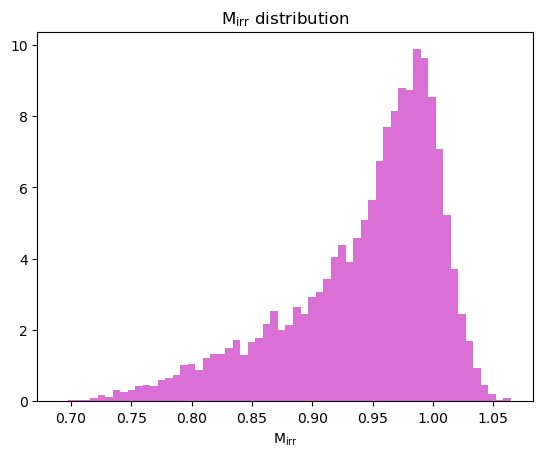

In [4]:
mu = 1 #all masses measured in terms of mu
sigma = 0.02

M = np.random.normal(loc=mu, scale=sigma, size=N_BHs)

M_irr = M*f(a)
plt.hist(M_irr, bins=60, density=True, color="orchid")
plt.xlabel("M$\\rm_{irr}$")
plt.title("M$\\rm_{irr}$ distribution")

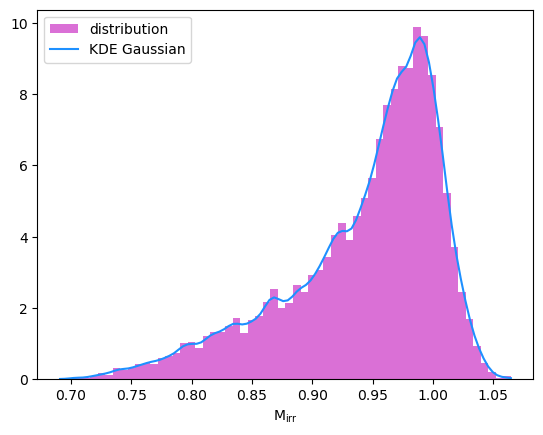

In [5]:
x = np.linspace(min(M_irr), max(M_irr), 100)

KDE_G = KernelDensity(bandwidth=0.005, kernel="gaussian").fit(M_irr[:, np.newaxis])
PDFGauss = np.exp(KDE_G.score_samples(x[:, np.newaxis]))

plt.hist(M_irr, bins=60, color="orchid", density=True, label="distribution")
plt.plot(x, PDFGauss, color="dodgerblue", label="KDE Gaussian")
plt.xlabel("M$\\rm_{irr}$")
plt.legend()

Text(0.5, 1.0, 'sigma = 1')

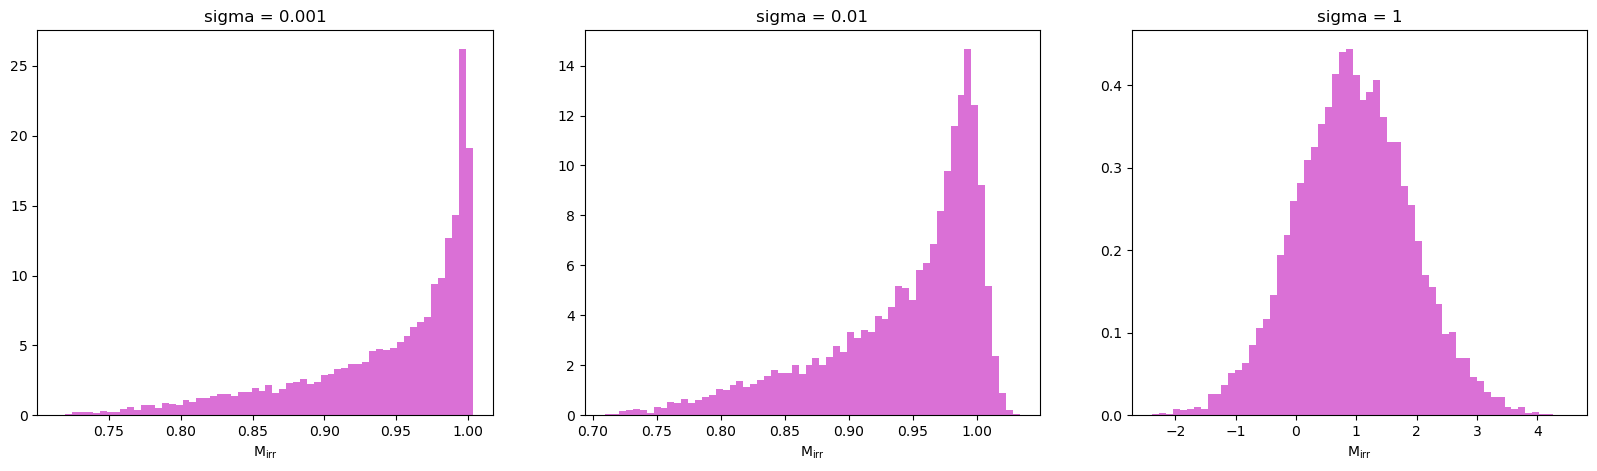

In [6]:
#looking at M_irr behaviour depending on sigma
fig = plt.figure(figsize=(20, 5))

ax1 = fig.add_subplot(131)
sigma1 = 0.001
M1 = np.random.normal(loc=mu, scale=sigma1, size=N_BHs)
M_irr1 = M1*f(a)
ax1.hist(M_irr1, bins=60, density=True, color="orchid")
ax1.set_xlabel("M$\\rm_{irr}$")
ax1.set_title("sigma = {}".format(sigma1))

ax2 = fig.add_subplot(132)
sigma2 = 0.01
M2 = np.random.normal(loc=mu, scale=sigma2, size=N_BHs)
M_irr2 = M2*f(a)
ax2.hist(M_irr2, bins=60, density=True, color="orchid")
ax2.set_xlabel("M$\\rm_{irr}$")
ax2.set_title("sigma = {}".format(sigma2))

ax3 = fig.add_subplot(133)
sigma3 = 1
M3 = np.random.normal(loc=mu, scale=sigma3, size=N_BHs)
M_irr3 = M3*f(a)
ax3.hist(M_irr3, bins=60, density=True, color="orchid")
ax3.set_xlabel("M$\\rm_{irr}$")
ax3.set_title("sigma = {}".format(sigma3))

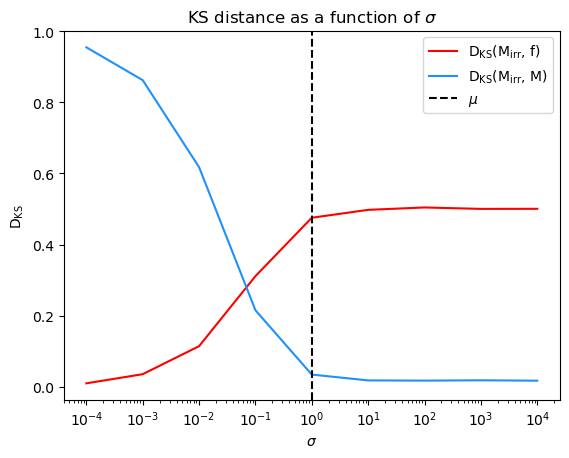

In [7]:
sigmas = np.logspace(-4, 4, 9)
D_f = np.zeros(len(sigmas))
D_M = np.zeros(len(sigmas))
for s in sigmas:
    Ms = np.random.normal(loc=mu, scale=s, size=N_BHs)
    D_f[sigmas==s] = stats.kstest(Ms*f(a), f(a))[0]
    D_M[sigmas==s] = stats.kstest(Ms*f(a), Ms)[0]
    
plt.plot(sigmas, D_f, color="red", label="D$\\rm_{KS}(M_{irr}$, f)")
plt.plot(sigmas, D_M, color="dodgerblue", label="D$\\rm_{KS}(M_{irr}$, M)")
plt.xlabel("$\\sigma$")
plt.xscale("log")
plt.ylabel("D$\\rm_{KS}$")
plt.axvline(mu, color="k", ls="--", label="$\\mu$")
plt.title("KS distance as a function of $\\sigma$")
plt.legend()

$M_{\rm irr}$ is distributed like:
- $f$ if $\sigma\ll\mu$, since $D_{KS}\ll$ for $\sigma\ll$
- $M$ if  $\sigma\gg\mu$, since $D_{KS}\ll$ for $\sigma\gg$

---

**pdf of f:**

from $p(f(a)) = \left|\frac{da}{df}\right| p(a)$:

$a$ is uniformly distributed in [0, 1], so $p(a)=1$

$a(f)=\sqrt{1-(2f^2-1/2)^2}$

$\frac{da}{df}=\frac{1}{2\sqrt{1-(2f^2-1)^2}}\cdot2(2f^2-1)\cdot4f=\frac{4f(2f^2-1)}{\sqrt{1-4f^4+4f^2-1}}=\frac{4f(2f^2-1)}{\sqrt{4f^2(f^2-1)}}=\frac{4f(2f^2-1)}{2f\sqrt{1-f^2}}$

$\pi(f)=2\frac{2f^2-1}{\sqrt{1-f^2}}$

...

$p(M_{\rm irr})=\frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}{\rm d}f$

Text(0.5, 1.0, 'comparison mathematical pdf - KDE')

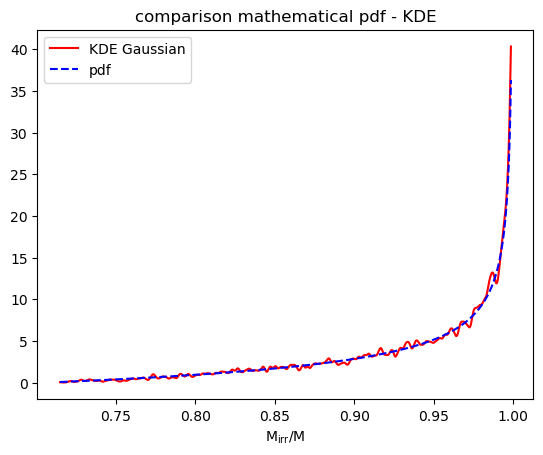

In [8]:
fx = np.linspace(min(f(a)), max(f(a)-0.0015), len(f(a)))
pdf_f = 2*(2*fx**2-1)/(np.sqrt(1-fx**2))


KDE_Gf = KernelDensity(bandwidth=0.001, kernel="gaussian").fit(f(a)[:, np.newaxis])
PDFGaussf = np.exp(KDE_Gf.score_samples(fx[:, np.newaxis]))
plt.plot(fx, PDFGaussf, "r", label="KDE Gaussian")
plt.plot(fx, pdf_f, "--b", label="pdf")
plt.xlabel("M$\\rm_{irr}/M$")
plt.legend()
plt.title("comparison mathematical pdf - KDE")

Text(0.5, 1.0, 'comparison mathematical pdf - KDE')

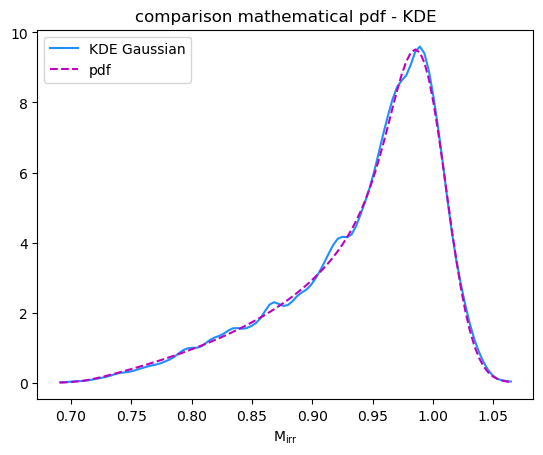

In [14]:
def I(Mx, fx): #to be integrated
    return (np.sqrt(2/np.pi)/sigma)*np.exp(-(Mx/fx-mu)**2/(2*sigma**2))*(2*fx**2-1)/(fx*np.sqrt(1-fx**2))

pdf_M_irr = [integrate.quad(lambda fx: I(M, fx), min(f(a)), max(f(a))-0.00001)[0] for M in x] #first is the integral value, second is the error
#had to subtract a small number to avoid divergence

plt.plot(x, PDFGauss, color="dodgerblue", label="KDE Gaussian")
plt.plot(x, pdf_M_irr, "--m", label="pdf")
plt.xlabel("M$\\rm_{irr}$")
plt.legend()
plt.title("comparison mathematical pdf - KDE")